# Lorenz-63 Gradient Blow-up Analysis

**Goal:** Demonstrate gradient explosion beyond the Lyapunov time horizon by computing gradients at **perturbed parameters** (ρ = 25, true value = 28) and plotting gradient norms vs window horizon T_w.

The key point: at the true parameters the loss is exactly zero and the gradient vanishes. To see gradient explosion we must evaluate at an incorrect parameter value, where the integrated trajectory diverges from the reference. As the window length grows beyond the Lyapunov time the mismatch—and hence the gradient magnitude—blows up exponentially.

In [19]:
import Pkg

# Activate the shared examples environment (one level up from basic_training/)
env_path = joinpath(@__DIR__, "..")
Pkg.activate(env_path)

# ── FIRST TIME ONLY ──────────────────────────────────────────────────────────
# Run these two lines once, then re-comment them.
# LorenzParameterEstimation is a local package — use dev, not add.
Pkg.develop(path = joinpath(@__DIR__, "..", ".."))   # links the local package
Pkg.add(["LaTeXStrings", "Colors", "Plots", "Statistics", "StatsBase"])
Pkg.instantiate()
# ─────────────────────────────────────────────────────────────────────────────

println("Active environment: ", Base.active_project())

  Activating project at `~/master_thesis/LorenzParameterEstimation/examples_weather`
   Resolving package versions...
  No Changes to `~/master_thesis/LorenzParameterEstimation/examples_weather/Project.toml`
  No Changes to `~/master_thesis/LorenzParameterEstimation/examples_weather/Manifest.toml`
   Resolving package versions...
  No Changes to `~/master_thesis/LorenzParameterEstimation/examples_weather/Project.toml`
  No Changes to `~/master_thesis/LorenzParameterEstimation/examples_weather/Manifest.toml`


Active environment: /Users/niklasviebig/master_thesis/LorenzParameterEstimation/examples_weather/Project.toml


In [20]:
using LinearAlgebra, Printf, Random, Statistics
using LorenzParameterEstimation
using Plots
using LaTeXStrings
using Colors

In [21]:
println("\n================ Setup ================")

# Reference parameters (classic Lorenz) — used to generate the target trajectory
params_ref = L63Parameters(10.0, 28.0, 8.0/3.0)
u0_ref = [1.0, 1.0, 1.0]
T_ref = 50.0
M_ref = 10_000
dt_ref = T_ref / M_ref

println("Reference parameters: σ=$(params_ref.σ), ρ=$(params_ref.ρ), β=$(params_ref.β)")
println("Time horizon: T=$(T_ref), timesteps: M=$(M_ref), dt=$(dt_ref)")

# Integrate reference trajectory
ref_sol = integrate(params_ref, u0_ref, (0.0, T_ref), dt_ref)
println("Reference trajectory length: $(length(ref_sol))")

# Use PERTURBED parameters for gradient computation — ρ wrong by 3 units
params_guess = L63Parameters(10.0, 25.0, 8.0/3.0)
println("\nTrue parameters:    σ=$(params_ref.σ), ρ=$(params_ref.ρ), β=$(params_ref.β)")
println("Perturbed params:   σ=$(params_guess.σ), ρ=$(params_guess.ρ), β=$(params_guess.β)")
println("(Computing gradient at perturbed ρ=25 — gradient at true optimum is identically zero)")

# Lyapunov exponent from Viswanath (1998): λ₁ ≈ 0.906 (units: 1/time)
# Lyapunov time τ_λ = 1/λ₁ ≈ 1.10 time units ≈ 220 steps
λ_est = 0.906
τ_λ = 1 / λ_est
println("\nLyapunov exponent λ ≈ $(round(λ_est, digits=3))")
println("Lyapunov time τ_λ ≈ $(round(τ_λ, digits=2)) time units = $(round(Int, τ_λ/dt_ref)) steps")


================ Setup ================
Reference parameters: σ=10.0, ρ=28.0, β=2.6666666666666665
Time horizon: T=50.0, timesteps: M=10000, dt=0.005
Reference trajectory length: 10001

True parameters:    σ=10.0, ρ=28.0, β=2.6666666666666665
Perturbed params:   σ=10.0, ρ=25.0, β=2.6666666666666665
(Computing gradient at perturbed ρ=25 — gradient at true optimum is identically zero)

Lyapunov exponent λ ≈ 0.906
Lyapunov time τ_λ ≈ 1.1 time units = 221 steps


In [22]:
println("\n================ Gradient Sweep (Multi-Start) ================")
println("Statistics computed in log10 space (log-normal is appropriate for data spanning orders of magnitude)\n")

Nw_list = unique(round.(Int, exp.(range(log(50), log(4500), length=22))))
Tw_list  = [Nw * dt_ref for Nw in Nw_list]

n_starts = 30
loss_fn  = window_rmse
rng      = Random.MersenneTwister(42)

# Store mean and std of log10(‖∇‖) — symmetric ribbon on log scale, no clamping needed
grad_means = Float64[]   # mean of log10(norm)
grad_stds  = Float64[]   # std  of log10(norm)

for Nw in Nw_list
    max_start = length(ref_sol) - Nw - 1
    if max_start < n_starts
        push!(grad_means, NaN); push!(grad_stds, NaN); continue
    end

    starts = rand(rng, 1:max_start, n_starts)
    log_norms = Float64[]

    for idx in starts
        try
            _, grads = compute_gradients_modular(params_guess, ref_sol, idx, Nw, loss_fn)
            g = sqrt(grads.σ^2 + grads.ρ^2 + grads.β^2)
            (isfinite(g) && g > 0) && push!(log_norms, log10(g))
        catch; end
    end

    μ = isempty(log_norms) ? NaN : mean(log_norms)
    s = length(log_norms) < 2 ? NaN : std(log_norms)
    push!(grad_means, μ)
    push!(grad_stds,  s)

    @printf("Nw=%4d  Tw=%5.2f τ_λ  mean(log10‖∇‖)=%6.3f  std=%5.3f  (n=%d/%d)\n",
            Nw, Nw*dt_ref/τ_λ, μ, s, length(log_norms), n_starts)
end
println("\nSweep complete.")


================ Gradient Sweep (Multi-Start) ================
Statistics computed in log10 space (log-normal is appropriate for data spanning orders of magnitude)

Nw=  50  Tw= 0.23 τ_λ  mean(log10‖∇‖)=-0.240  std=0.144  (n=30/30)
Nw=  62  Tw= 0.28 τ_λ  mean(log10‖∇‖)=-0.122  std=0.103  (n=30/30)
Nw=  77  Tw= 0.35 τ_λ  mean(log10‖∇‖)=-0.097  std=0.200  (n=30/30)
Nw=  95  Tw= 0.43 τ_λ  mean(log10‖∇‖)=-0.025  std=0.218  (n=30/30)
Nw= 118  Tw= 0.53 τ_λ  mean(log10‖∇‖)= 0.160  std=0.214  (n=30/30)
Nw= 146  Tw= 0.66 τ_λ  mean(log10‖∇‖)= 0.211  std=0.335  (n=30/30)
Nw= 181  Tw= 0.82 τ_λ  mean(log10‖∇‖)= 0.428  std=0.324  (n=30/30)
Nw= 224  Tw= 1.01 τ_λ  mean(log10‖∇‖)= 0.337  std=0.379  (n=30/30)
Nw= 278  Tw= 1.26 τ_λ  mean(log10‖∇‖)= 0.484  std=0.389  (n=30/30)
Nw= 344  Tw= 1.56 τ_λ  mean(log10‖∇‖)= 0.353  std=0.458  (n=30/30)
Nw= 426  Tw= 1.93 τ_λ  mean(log10‖∇‖)= 0.577  std=0.503  (n=30/30)
Nw= 528  Tw= 2.39 τ_λ  mean(log10‖∇‖)= 0.530  std=0.487  (n=30/30)
Nw= 654  Tw= 2.96 τ_λ  mean(lo

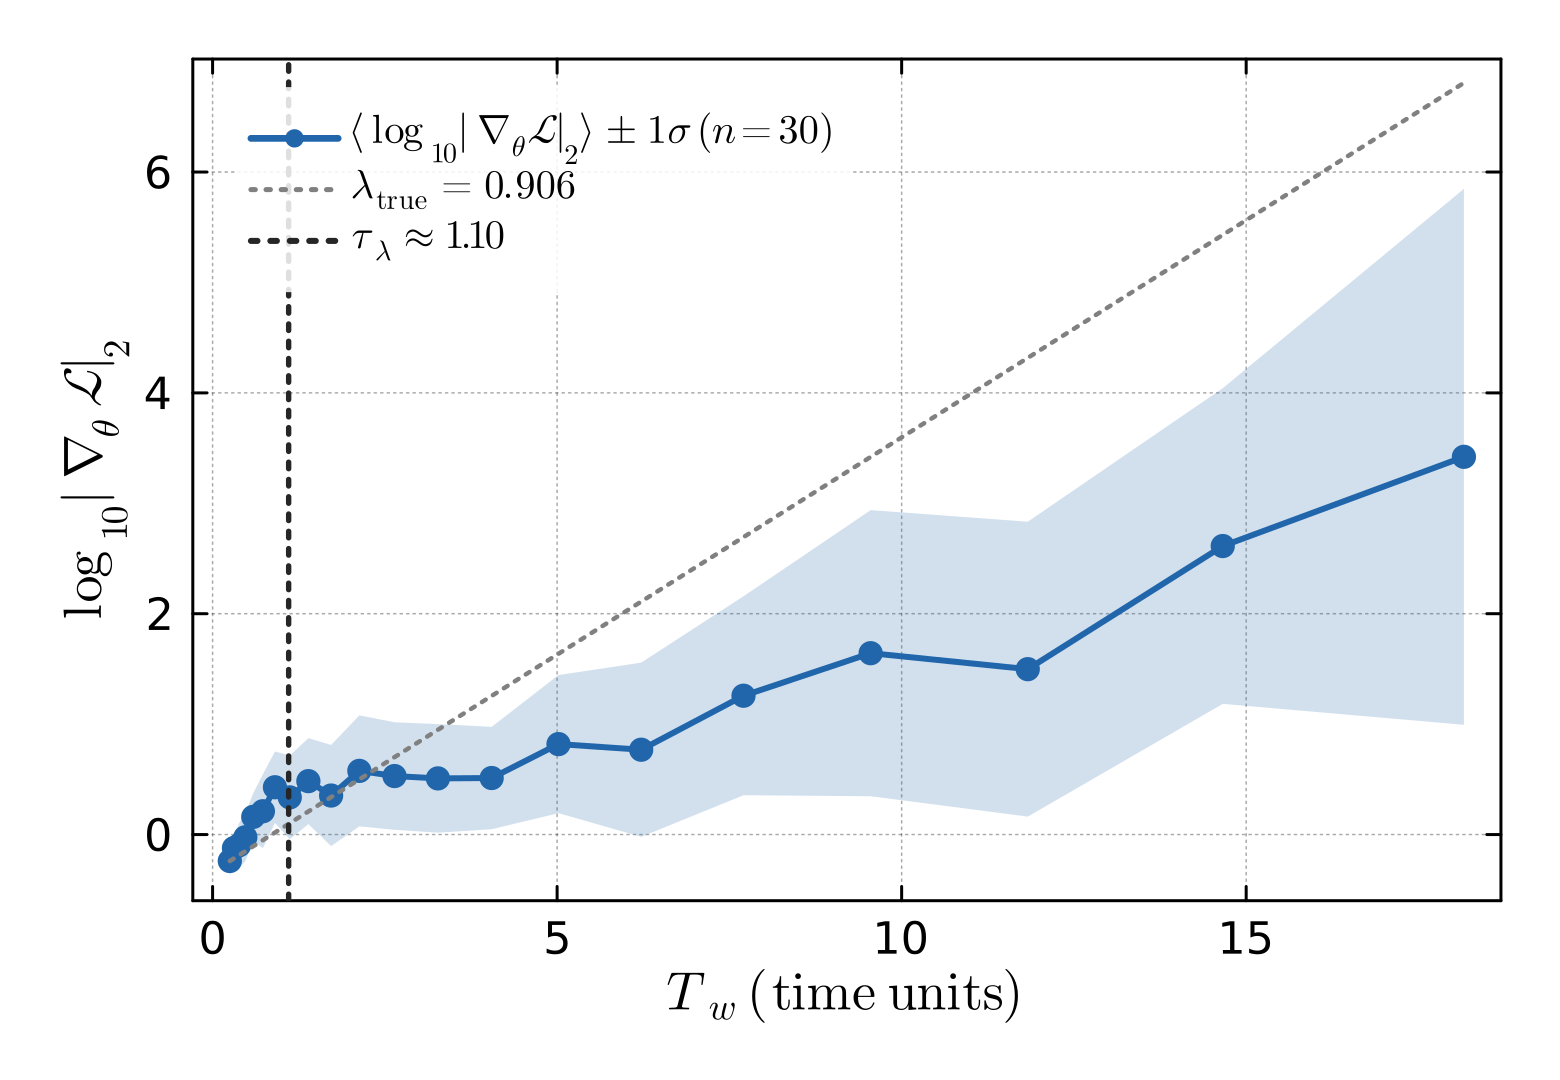


================ Publication-Quality Plot ================
Linear fit slope b = 0.1718  →  λ_fit = b·ln(10) = 0.3955  (λ_true = 0.906)
✓ Saved publication figures


In [23]:
println("\n================ Publication-Quality Plot ================")

valid = isfinite.(grad_means) .& isfinite.(grad_stds)
Tw_v = Tw_list[valid][1:end-1]
μ_v  = grad_means[valid][1:end-1]   # mean of log10(norm)
σ_v  = grad_stds[valid][1:end-1]    # std  of log10(norm) — symmetric ribbon in log space

# ── linear fit in log10 space: log10(‖∇‖) = a + b·T_w  →  λ_fit = b·ln(10) ─
A       = [ones(length(Tw_v)) Tw_v]
coeffs  = A \ μ_v
b_fit   = coeffs[2]
λ_fit   = b_fit * log(10)
fit_line = coeffs[1] .+ b_fit .* Tw_v
@printf("Linear fit slope b = %.4f  →  λ_fit = b·ln(10) = %.4f  (λ_true = %.3f)\n",
        b_fit, λ_fit, λ_est)

# ── exponential reference (theoretical) ──────────────────────────────────────
t_ref_line  = range(Tw_v[1], Tw_v[end], length=400)
log_exp_ref = μ_v[1] .+ (λ_est / log(10)) .* (t_ref_line .- Tw_v[1])

col_line  = RGB(0.13, 0.40, 0.67)
col_ref   = RGB(0.50, 0.50, 0.50)
col_fit   = RGB(0.84, 0.37, 0.10)   # orange for fit
col_vline = RGB(0.15, 0.15, 0.15)

p = plot(
    Tw_v, μ_v;
    ribbon            = σ_v,
    fillalpha         = 0.20,
    fillcolor         = col_line,
    linecolor         = col_line,
    linewidth         = 2.0,
    markershape       = :circle,
    markersize        = 4.5,
    markercolor       = col_line,
    markerstrokewidth = 0,
    label             = L"\langle\log_{10}\|\nabla_\theta\mathcal{L}\|_2\rangle \pm 1\sigma\;(n\!=\!30)",
    xlabel      = L"T_w \; (\mathrm{time\; units})",
    ylabel      = L"\log_{10}\|\nabla_{\!\theta}\,\mathcal{L}\|_2",
    size        = (520, 360),
    dpi         = 300,
    left_margin   = 5Plots.mm,
    bottom_margin = 4Plots.mm,
    right_margin  = 3Plots.mm,
    top_margin    = 3Plots.mm,
    guidefontsize  = 12,
    tickfontsize   = 10,
    legendfontsize = 9,
    grid        = true,
    gridalpha   = 0.18,
    gridstyle   = :dot,
    framestyle  = :box,
    legend      = :topleft,
    foreground_color_legend = nothing,
    background_color_legend = RGBA(1, 1, 1, 0.85),
)

# theoretical Lyapunov reference
plot!(p, t_ref_line, log_exp_ref;
      linecolor = col_ref,
      linestyle = :dot,
      linewidth = 1.5,
      label     = L"\lambda_{\mathrm{true}}=0.906")

vline!(p, [τ_λ];
       linecolor = col_vline,
       linestyle = :dot,
       linewidth = 1.8,
       label     = L"\tau_\lambda \approx 1.10")

display(p)

savefig(p, joinpath(@__DIR__, "lorenz_gradient_blowup_vs_window.pdf"))
savefig(p, joinpath(@__DIR__, "lorenz_gradient_blowup_vs_window.png"))
println("✓ Saved publication figures")

In [24]:
println("\n================ Per-Parameter Gradient Sweep ================")
println("Same experiment, but tracking ∂L/∂σ, ∂L/∂ρ, ∂L/∂β separately\n")

rng2 = Random.MersenneTwister(42)   # same seed → same windows as above

# Accumulate mean/std for each parameter component
σ_means = Float64[]; σ_stds = Float64[]
ρ_means = Float64[]; ρ_stds = Float64[]
β_means = Float64[]; β_stds = Float64[]

for Nw in Nw_list
    max_start = length(ref_sol) - Nw - 1
    if max_start < n_starts
        for v in (σ_means, σ_stds, ρ_means, ρ_stds, β_means, β_stds)
            push!(v, NaN)
        end
        continue
    end

    starts = rand(rng2, 1:max_start, n_starts)
    gs = Float64[]; gρ = Float64[]; gb = Float64[]

    for idx in starts
        try
            _, grads = compute_gradients_modular(params_guess, ref_sol, idx, Nw, loss_fn)
            ag = abs(grads.σ); aρ = abs(grads.ρ); ab = abs(grads.β)
            if isfinite(ag) && ag > 0; push!(gs, log10(ag)); end
            if isfinite(aρ) && aρ > 0; push!(gρ, log10(aρ)); end
            if isfinite(ab) && ab > 0; push!(gb, log10(ab)); end
        catch; end
    end

    push!(σ_means, isempty(gs) ? NaN : mean(gs));  push!(σ_stds, length(gs)<2 ? NaN : std(gs))
    push!(ρ_means, isempty(gρ) ? NaN : mean(gρ));  push!(ρ_stds, length(gρ)<2 ? NaN : std(gρ))
    push!(β_means, isempty(gb) ? NaN : mean(gb));  push!(β_stds, length(gb)<2 ? NaN : std(gb))

    @printf("Nw=%4d  |∂σ|=%8.3e  |∂ρ|=%8.3e  |∂β|=%8.3e\n",
            Nw, σ_means[end], ρ_means[end], β_means[end])
end
println("\nPer-parameter sweep complete.")


================ Per-Parameter Gradient Sweep ================
Same experiment, but tracking ∂L/∂σ, ∂L/∂ρ, ∂L/∂β separately

Nw=  50  |∂σ|=-1.482e+00  |∂ρ|=-2.772e-01  |∂β|=-8.526e-01
Nw=  62  |∂σ|=-1.424e+00  |∂ρ|=-2.003e-01  |∂β|=-6.696e-01
Nw=  77  |∂σ|=-1.256e+00  |∂ρ|=-2.933e-01  |∂β|=-4.661e-01
Nw=  95  |∂σ|=-1.141e+00  |∂ρ|=-2.054e-01  |∂β|=-4.192e-01
Nw= 118  |∂σ|=-1.054e+00  |∂ρ|=-5.255e-02  |∂β|=-1.704e-01
Nw= 146  |∂σ|=-9.479e-01  |∂ρ|=-6.117e-02  |∂β|=-1.897e-01
Nw= 181  |∂σ|=-9.295e-01  |∂ρ|=-5.992e-03  |∂β|=3.291e-01
Nw= 224  |∂σ|=-8.605e-01  |∂ρ|=-1.302e-02  |∂β|=2.031e-01
Nw= 278  |∂σ|=-9.533e-01  |∂ρ|=-9.609e-02  |∂β|=3.893e-01
Nw= 344  |∂σ|=-1.083e+00  |∂ρ|=-8.679e-02  |∂β|=1.412e-01
Nw= 426  |∂σ|=-6.037e-01  |∂ρ|=-3.112e-02  |∂β|=4.287e-01
Nw= 528  |∂σ|=-7.322e-01  |∂ρ|=-6.931e-02  |∂β|=3.671e-01
Nw= 654  |∂σ|=-7.066e-01  |∂ρ|=-2.826e-01  |∂β|=3.605e-01
Nw= 810  |∂σ|=-7.588e-01  |∂ρ|=-2.423e-01  |∂β|=3.973e-01
Nw=1004  |∂σ|=-5.654e-01  |∂ρ|=-2.143e-02  |∂β|=7.727e-0

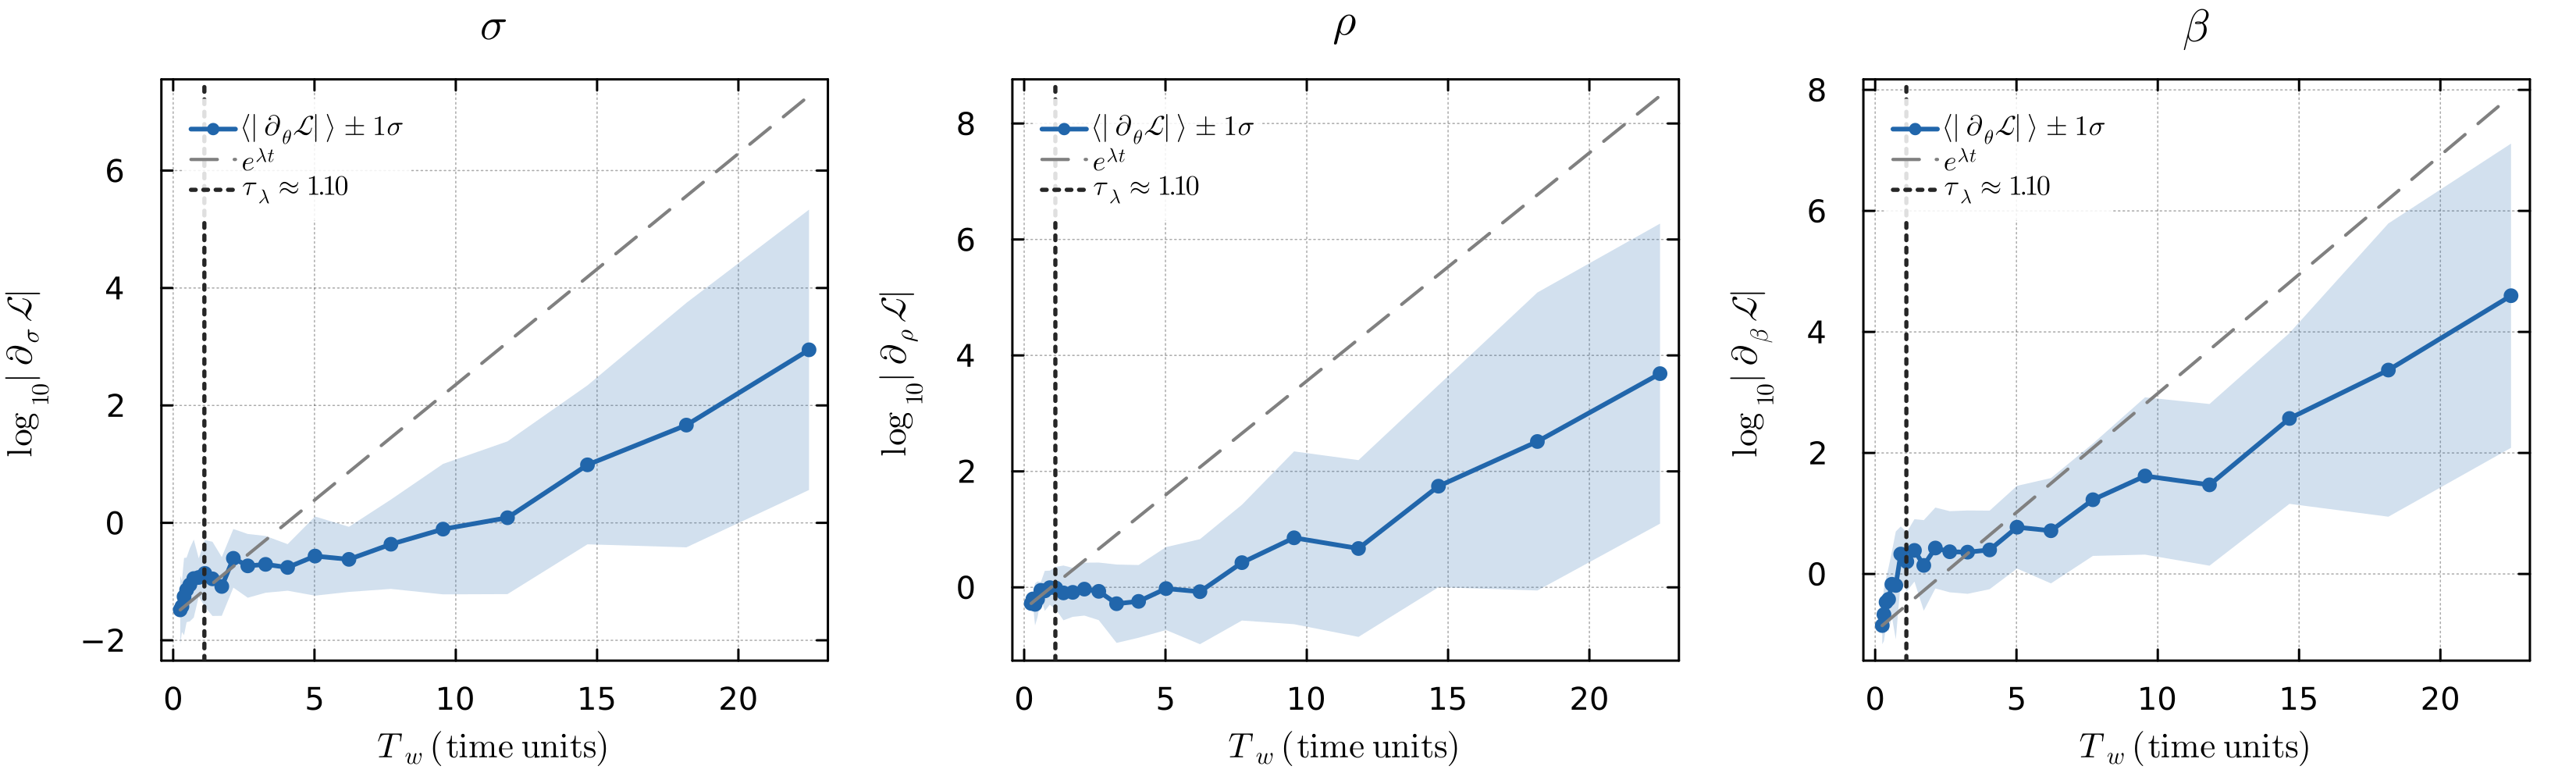


================ Per-Parameter Plot ================
✓ Saved per-parameter figures


In [25]:
println("\n================ Per-Parameter Plot ================")

param_data = [
    (σ_means, σ_stds, L"\sigma", L"\log_{10}\|\partial_\sigma\,\mathcal{L}\|"),
    (ρ_means, ρ_stds, L"\rho",   L"\log_{10}\|\partial_\rho\,\mathcal{L}\|"),
    (β_means, β_stds, L"\beta",  L"\log_{10}\|\partial_\beta\,\mathcal{L}\|"),
]

plots_list = []
for (means, stds, param_name, ylabel_str) in param_data
    valid = isfinite.(means) .& isfinite.(stds)
    Tw_v = Tw_list[valid]
    μ_v  = means[valid]
    σ_v  = stds[valid]

    # μ_v and σ_v are already in log10 space — symmetric ribbon
    t_ref_line  = range(Tw_v[1], Tw_v[end], length=400)
    log_exp_ref = μ_v[1] .+ (λ_est / log(10)) .* (t_ref_line .- Tw_v[1])

    pp = plot(
        Tw_v, μ_v;
        ribbon            = σ_v,
        fillalpha         = 0.20,
        fillcolor         = col_line,
        linecolor         = col_line,
        linewidth         = 2.0,
        markershape       = :circle,
        markersize        = 3.5,
        markercolor       = col_line,
        markerstrokewidth = 0,
        label             = L"\langle\|\partial_\theta\mathcal{L}\|\rangle \pm 1\sigma",
        xlabel        = L"T_w \; (\mathrm{time\; units})",
        ylabel        = ylabel_str,
        title         = param_name,
        titlefontsize = 13,
        guidefontsize = 10,
        tickfontsize  = 9,
        legendfontsize = 8,
        grid        = true,
        gridalpha   = 0.18,
        gridstyle   = :dot,
        framestyle  = :box,
        legend      = :topleft,
        foreground_color_legend = nothing,
        background_color_legend = RGBA(1,1,1,0.85),
    )

    plot!(pp, t_ref_line, log_exp_ref;
          linecolor = col_ref,
          linestyle = :dash,
          linewidth = 1.4,
          label     = L"e^{\lambda t}")

    vline!(pp, [τ_λ];
           linecolor = col_vline,
           linestyle = :dot,
           linewidth = 1.8,
           label     = L"\tau_\lambda \approx 1.10")

    push!(plots_list, pp)
end

p3 = plot(plots_list...; layout=(1,3), size=(1100, 330),
          dpi=300,
          left_margin=5Plots.mm, bottom_margin=5Plots.mm,
          right_margin=3Plots.mm, top_margin=4Plots.mm)

display(p3)

savefig(p3, joinpath(@__DIR__, "lorenz_gradient_blowup_per_param.pdf"))
savefig(p3, joinpath(@__DIR__, "lorenz_gradient_blowup_per_param.png"))
println("✓ Saved per-parameter figures")

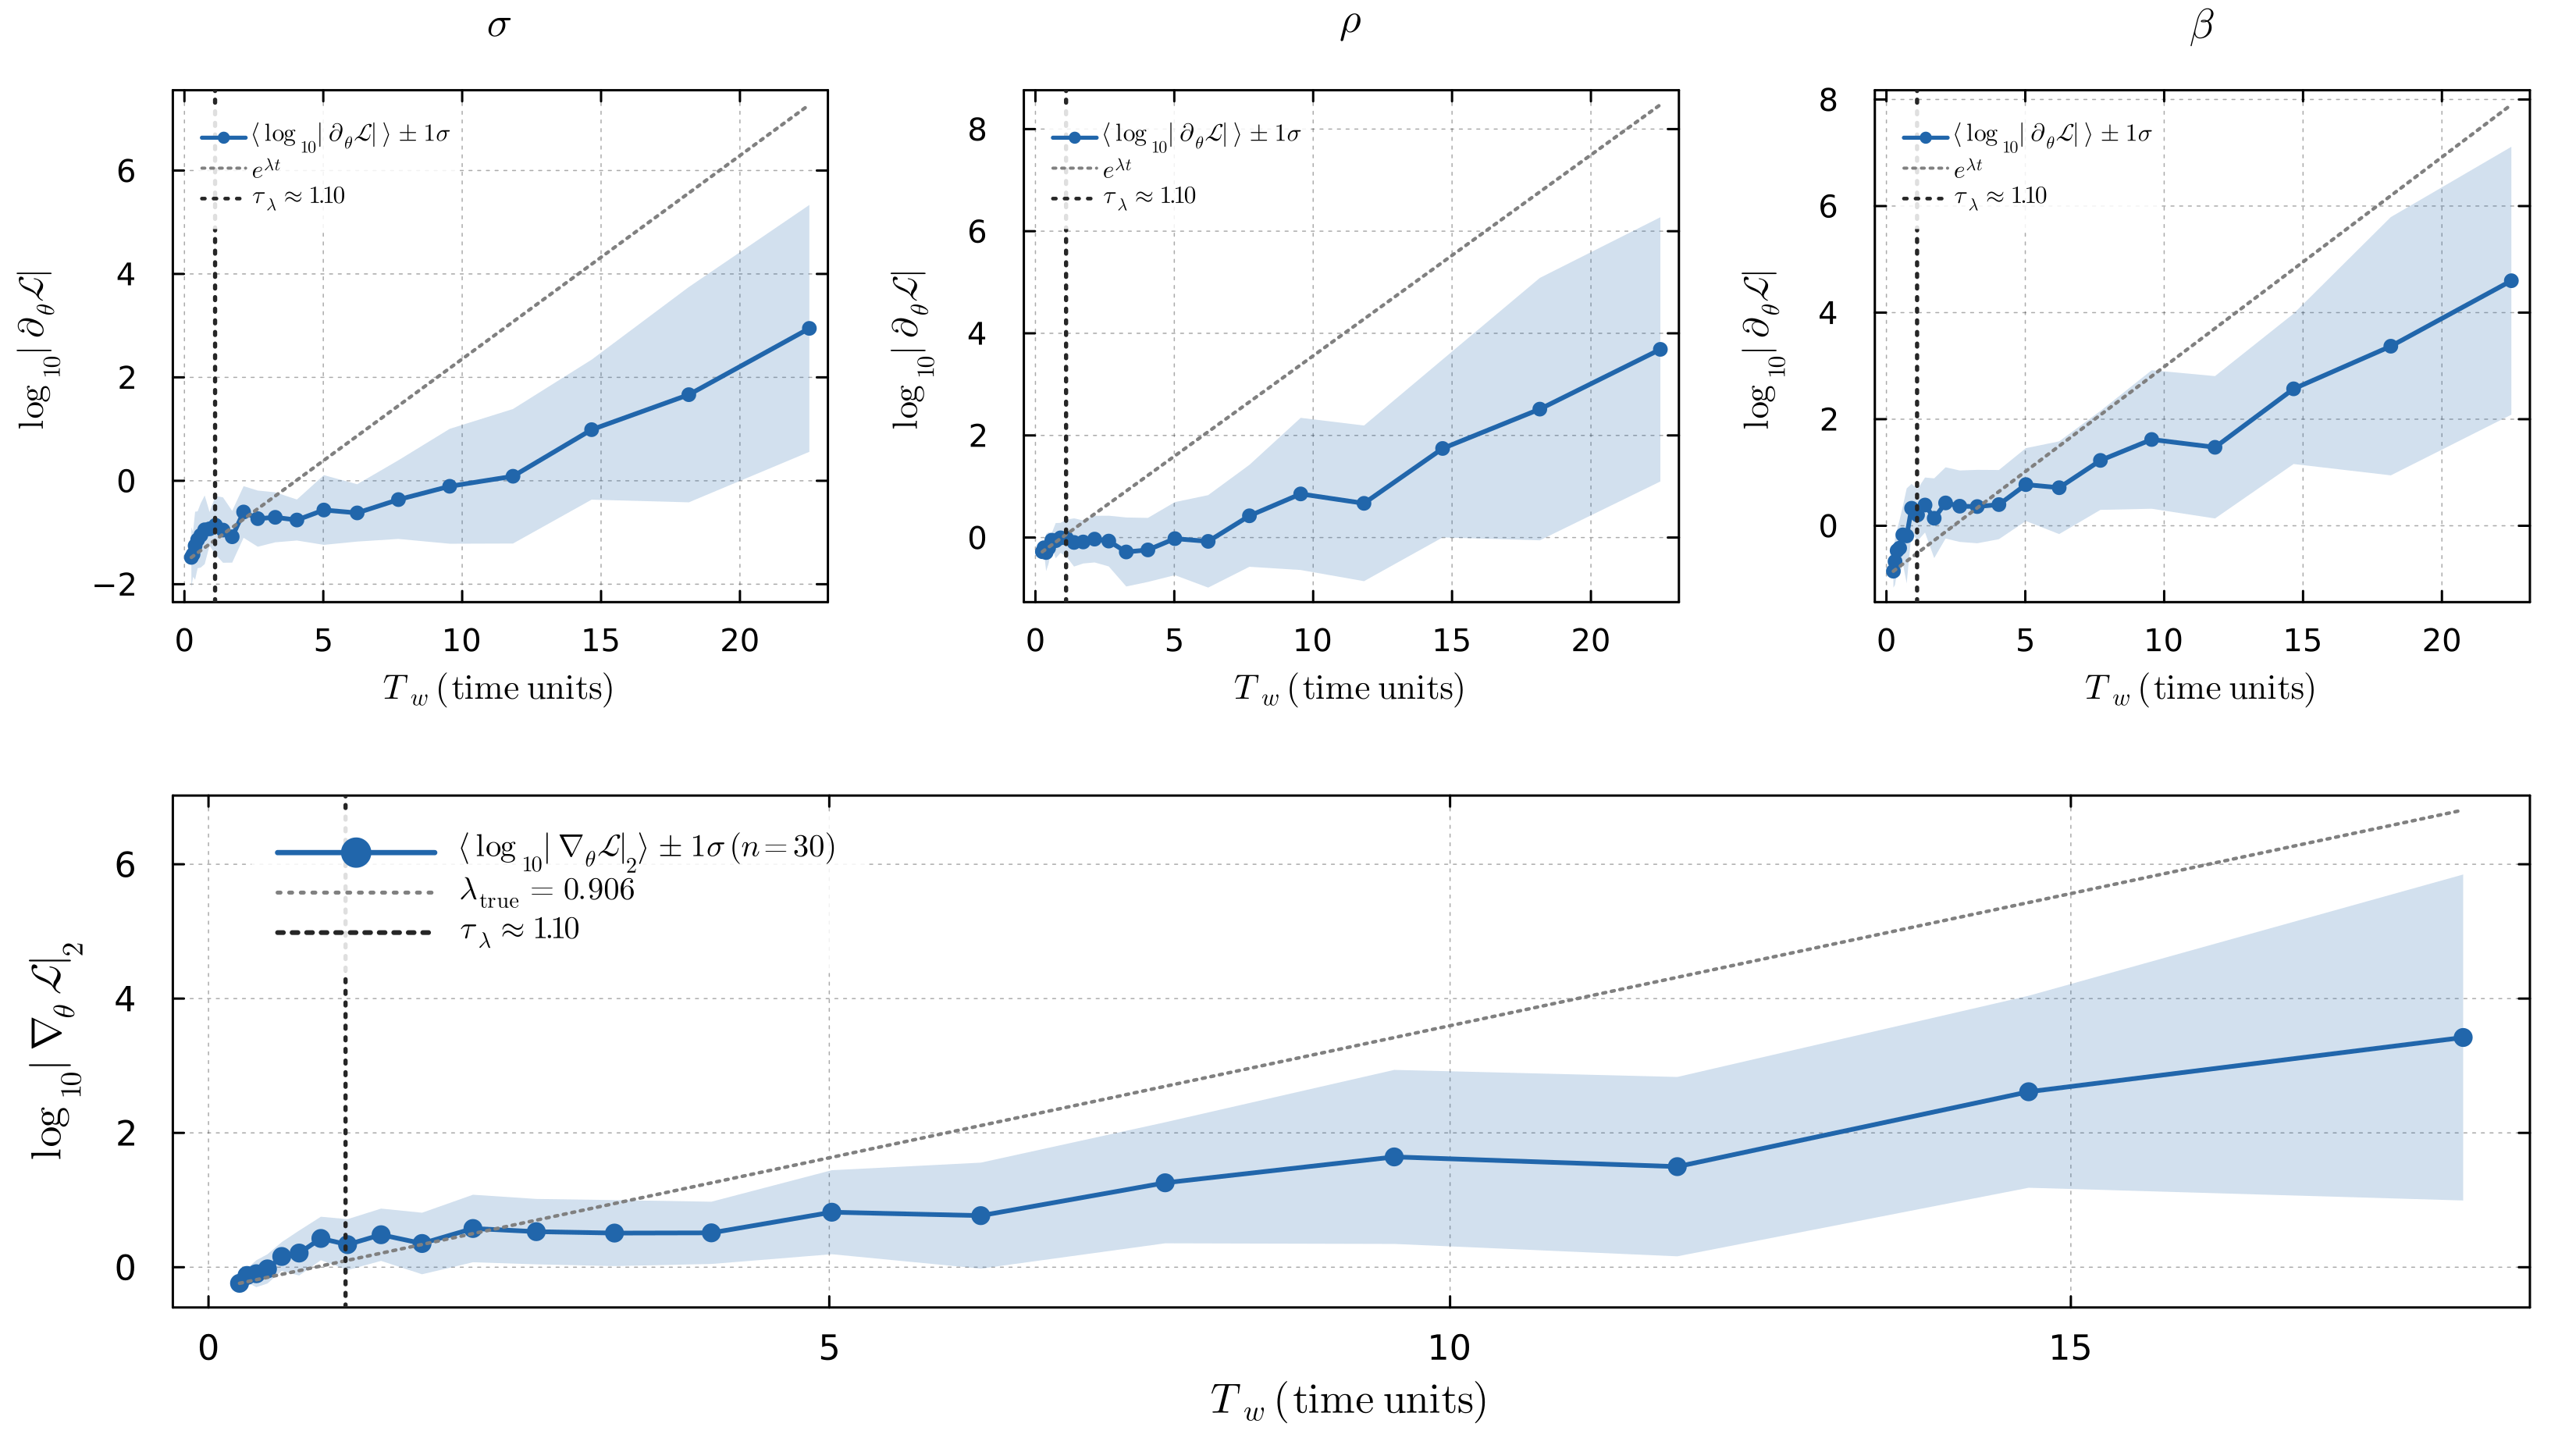


================ Combined Publication Figure ================
✓ Saved combined figure


In [26]:
println("\n================ Combined Publication Figure ================")

# ── combined-norm panel (reuses grad_means/grad_stds from Cell 4) ─────────────
valid_c  = isfinite.(grad_means) .& isfinite.(grad_stds)
Tw_c     = Tw_list[valid_c][1:end-1]
μ_c      = grad_means[valid_c][1:end-1]
σ_c      = grad_stds[valid_c][1:end-1]

t_ref_c      = range(Tw_c[1], Tw_c[end], length=400)
log_exp_ref_c = μ_c[1] .+ (λ_est / log(10)) .* (t_ref_c .- Tw_c[1])

# ── per-parameter panels (reuses σ/ρ/β _means/_stds from Cell 6) ─────────────
param_data = [
    (σ_means, σ_stds, L"\sigma"),
    (ρ_means, ρ_stds, L"\rho"),
    (β_means, β_stds, L"\beta"),
]

sub_plots = []
for (means, stds, pname) in param_data
    valid = isfinite.(means) .& isfinite.(stds)
    Tw_v  = Tw_list[valid]
    μ_v   = means[valid]
    σ_v   = stds[valid]

    t_ref   = range(Tw_v[1], Tw_v[end], length=400)
    ref_log = μ_v[1] .+ (λ_est / log(10)) .* (t_ref .- Tw_v[1])

    pp = plot(
        Tw_v, μ_v;
        ribbon            = σ_v,
        fillalpha         = 0.20,
        fillcolor         = col_line,
        linecolor         = col_line,
        linewidth         = 2.0,
        markershape       = :circle,
        markersize        = 3.5,
        markercolor       = col_line,
        markerstrokewidth = 0,
        label             = L"\langle\log_{10}|\partial_\theta\mathcal{L}|\rangle \pm 1\sigma",
        xlabel        = L"T_w \; (\mathrm{time\; units})",
        ylabel        = L"\log_{10}|\partial_\theta\mathcal{L}|",
        title         = pname,
        titlefontsize = 12,
        guidefontsize = 10,
        tickfontsize  = 9,
        legendfontsize = 7,
        grid       = true,
        gridalpha  = 0.18,
        gridstyle  = :dot,
        framestyle = :box,
        legend     = :topleft,
        foreground_color_legend = nothing,
        background_color_legend = RGBA(1,1,1,0.85),
    )
    plot!(pp, t_ref, ref_log;
          linecolor = col_ref, linestyle = :dot, linewidth = 1.5,
          label = L"e^{\lambda t}")
    vline!(pp, [τ_λ];
           linecolor = col_vline, linestyle = :dot, linewidth = 1.8,
           label = L"\tau_\lambda \approx 1.10")
    push!(sub_plots, pp)
end

# ── bottom panel: combined norm ────────────────────────────────────────────────
p_norm = plot(
    Tw_c, μ_c;
    ribbon            = σ_c,
    fillalpha         = 0.20,
    fillcolor         = col_line,
    linecolor         = col_line,
    linewidth         = 2.0,
    markershape       = :circle,
    markersize        = 4.5,
    markercolor       = col_line,
    markerstrokewidth = 0,
    label             = L"\langle\log_{10}\|\nabla_\theta\mathcal{L}\|_2\rangle \pm 1\sigma\;(n\!=\!30)",
    xlabel      = L"T_w \; (\mathrm{time\; units})",
    ylabel      = L"\log_{10}\|\nabla_{\!\theta}\,\mathcal{L}\|_2",
    guidefontsize  = 12,
    tickfontsize   = 10,
    legendfontsize = 9,
    grid        = true,
    gridalpha   = 0.18,
    gridstyle   = :dot,
    framestyle  = :box,
    legend      = :topleft,
    foreground_color_legend = nothing,
    background_color_legend = RGBA(1,1,1,0.85),
)
plot!(p_norm, t_ref_c, log_exp_ref_c;
      linecolor = col_ref, linestyle = :dot, linewidth = 1.5,
      label = L"\lambda_{\mathrm{true}} = 0.906")
vline!(p_norm, [τ_λ];
       linecolor = col_vline, linestyle = :dot, linewidth = 1.8,
       label = L"\tau_\lambda \approx 1.10")

# ── assemble 2-row layout: [σ  ρ  β] / [  combined norm (full width)  ] ──────
l = @layout [a b c; d]
p_combined = plot(
    sub_plots..., p_norm;
    layout        = l,
    size          = (1100, 620),
    dpi           = 300,
    left_margin   = 5Plots.mm,
    bottom_margin = 5Plots.mm,
    right_margin  = 3Plots.mm,
    top_margin    = 4Plots.mm,
)

display(p_combined)

savefig(p_combined, joinpath(@__DIR__, "lorenz_gradient_blowup_combined.pdf"))
savefig(p_combined, joinpath(@__DIR__, "lorenz_gradient_blowup_combined.png"))
println("✓ Saved combined figure")


================ Gradient Uncertainty Figure ================
Two-panel: (a) mean ± 1σ ribbon with fitted growth rate, (b) σ = uncertainty in orders of magnitude

Fitting over 14 points with T_w ≤ 5.0 time units
Fitted slope b = 0.1811  →  λ_fit = b·ln(10) = 0.4170  (λ_Lyapunov = 0.906)
✓ Saved lorenz_gradient_uncertainty.pdf / .png

Key σ values:
  T_w =  0.25 t.u. =  0.23 τ_λ  →  σ = 0.144  (±1σ spans 1.9× = 10^0.29 in original space)
  T_w =  0.31 t.u. =  0.28 τ_λ  →  σ = 0.103  (±1σ spans 1.6× = 10^0.21 in original space)
  T_w =  0.39 t.u. =  0.35 τ_λ  →  σ = 0.200  (±1σ spans 2.5× = 10^0.40 in original space)
  T_w =  0.48 t.u. =  0.43 τ_λ  →  σ = 0.218  (±1σ spans 2.7× = 10^0.44 in original space)
  T_w =  0.59 t.u. =  0.53 τ_λ  →  σ = 0.214  (±1σ spans 2.7× = 10^0.43 in original space)
  T_w =  0.73 t.u. =  0.66 τ_λ  →  σ = 0.335  (±1σ spans 4.7× = 10^0.67 in original space)
  T_w =  0.91 t.u. =  0.82 τ_λ  →  σ = 0.324  (±1σ spans 4.4× = 10^0.65 in original space)
  T_w =  1.1

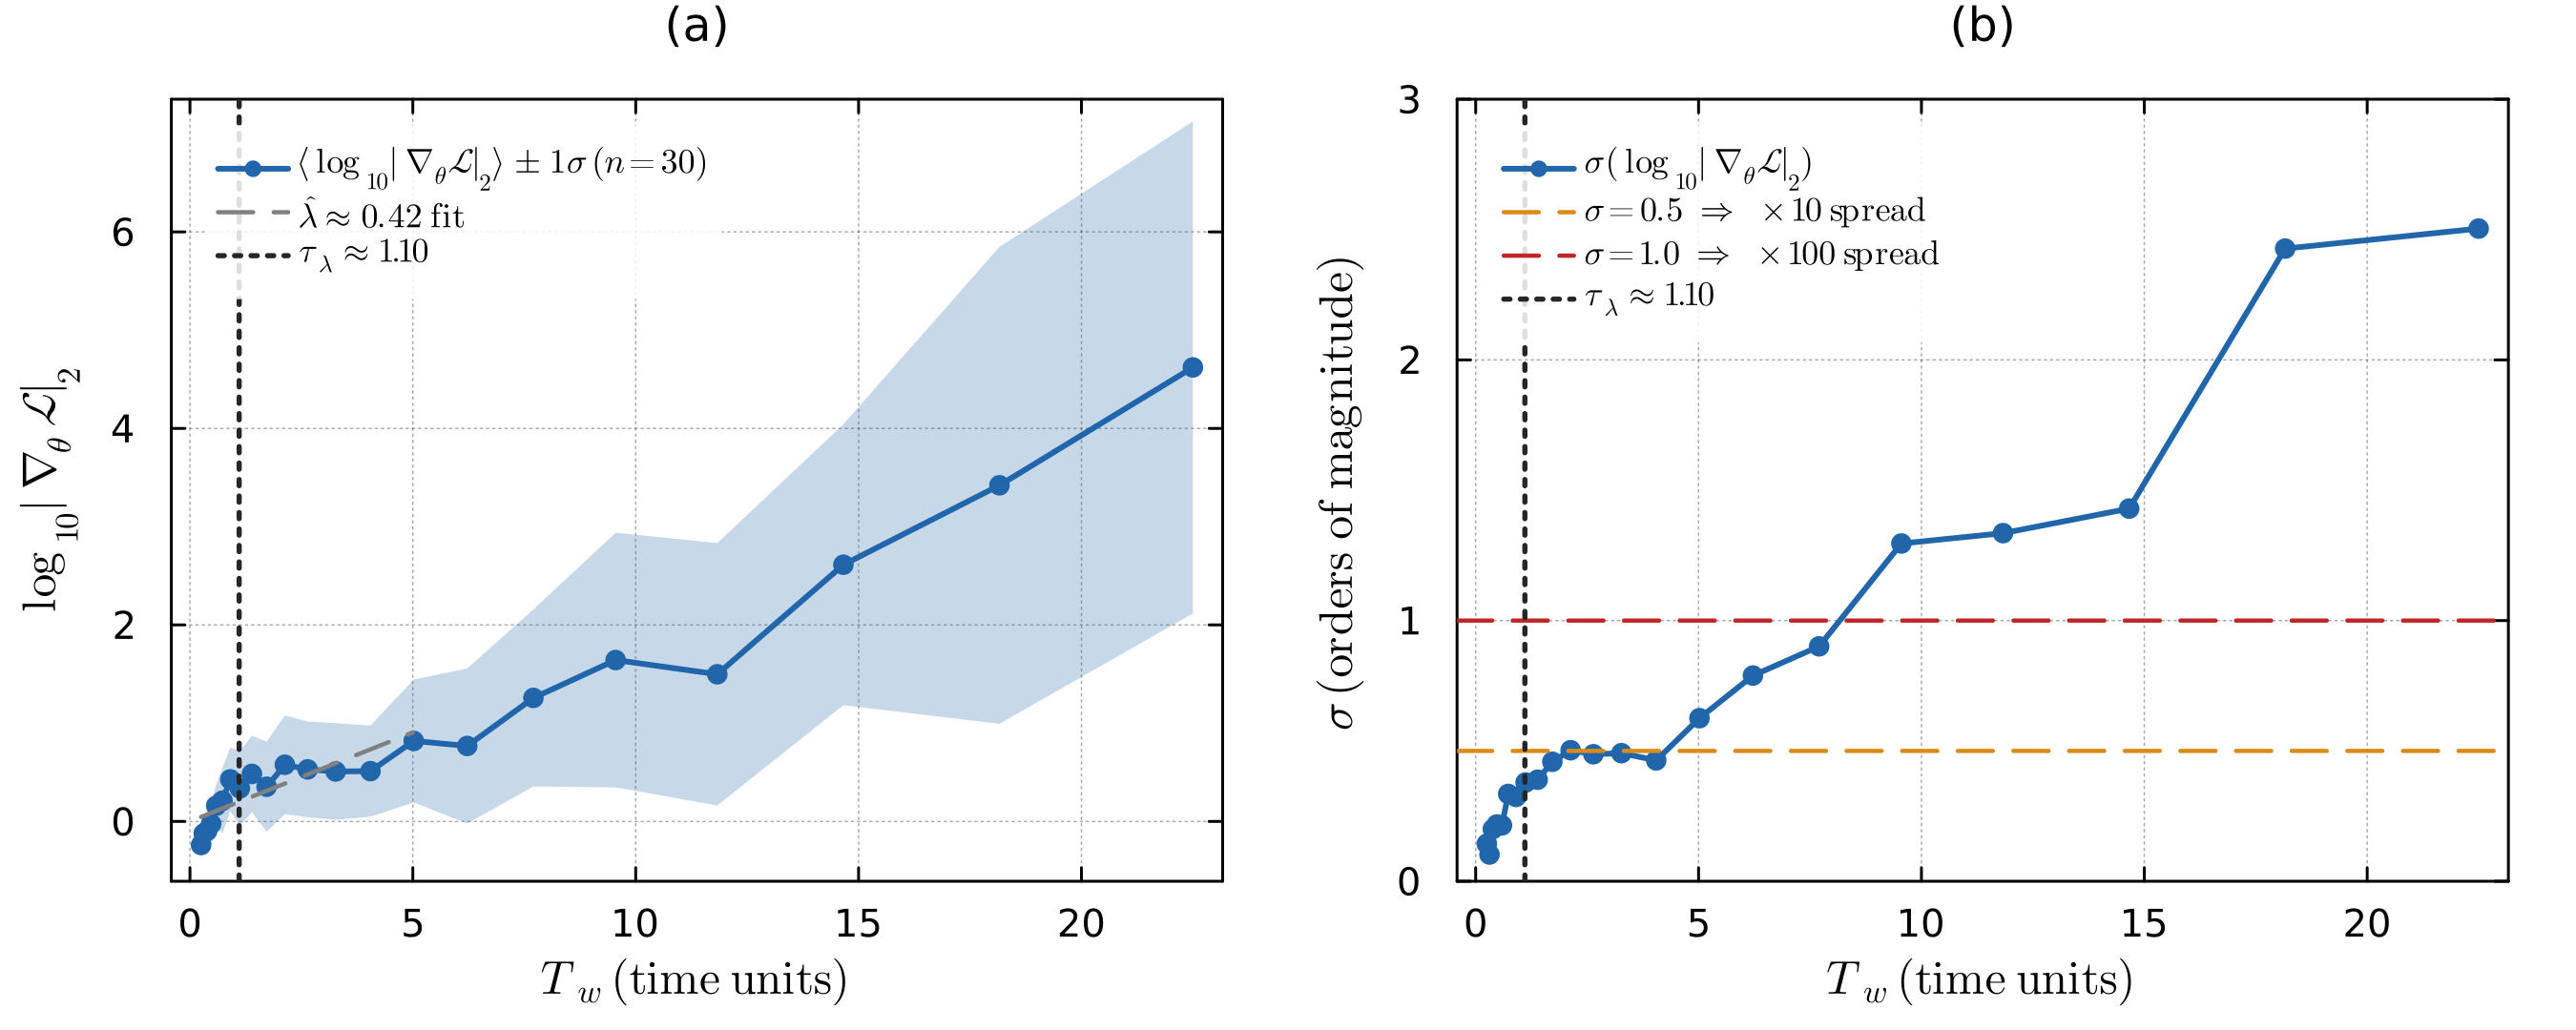

In [28]:
println("\n================ Gradient Uncertainty Figure ================")
println("Two-panel: (a) mean ± 1σ ribbon with fitted growth rate, (b) σ = uncertainty in orders of magnitude\n")

valid_u = isfinite.(grad_means) .& isfinite.(grad_stds)
Tw_u    = Tw_list[valid_u]
μ_u     = grad_means[valid_u]
σ_u     = grad_stds[valid_u]

# ── Fit actual growth rate — restrict to early growth regime (T_w ≤ 5 τ_λ) ──
# log10(‖∇‖) = a + b·T_w  →  λ_fit = b·ln(10)
T_fit_max = 5.0   # time units; beyond this gradients saturate
mask_fit  = Tw_u .<= T_fit_max
@printf("Fitting over %d points with T_w ≤ %.1f time units\n", sum(mask_fit), T_fit_max)
A_fit    = [ones(sum(mask_fit)) Tw_u[mask_fit]]
c_fit    = A_fit \ μ_u[mask_fit]
b_fit    = c_fit[2]
λ_fit    = b_fit * log(10)
@printf("Fitted slope b = %.4f  →  λ_fit = b·ln(10) = %.4f  (λ_Lyapunov = %.3f)\n",
        b_fit, λ_fit, λ_est)

t_ref_u  = range(Tw_u[1], T_fit_max, length=200)
fit_line = c_fit[1] .+ b_fit .* t_ref_u   # fitted line (early growth regime only)

col_thresh1 = RGB(0.85, 0.55, 0.10)   # orange  — σ = 0.5 threshold
col_thresh2 = RGB(0.75, 0.15, 0.15)   # red     — σ = 1.0 threshold

# ── Panel (a): mean ± 1σ ribbon + fitted growth line ─────────────────────────
fit_label = latexstring("\\hat{\\lambda}\\approx $(round(λ_fit, digits=2))\\;\\mathrm{fit}")

p_a = plot(
    Tw_u, μ_u;
    ribbon            = σ_u,
    fillalpha         = 0.25,
    fillcolor         = col_line,
    linecolor         = col_line,
    linewidth         = 2.0,
    markershape       = :circle,
    markersize        = 4.0,
    markercolor       = col_line,
    markerstrokewidth = 0,
    label             = L"\langle\log_{10}\|\nabla_\theta\mathcal{L}\|_2\rangle \pm 1\sigma\;(n\!=\!30)",
    xlabel      = L"T_w \; \mathrm{(time\; units)}",
    ylabel      = L"\log_{10}\|\nabla_{\!\theta}\,\mathcal{L}\|_2",
    title       = "(a)",
    titlefontsize  = 11,
    guidefontsize  = 11,
    tickfontsize   = 9,
    legendfontsize = 8,
    grid        = true,
    gridalpha   = 0.18,
    gridstyle   = :dot,
    framestyle  = :box,
    legend      = :topleft,
    foreground_color_legend = nothing,
    background_color_legend = RGBA(1,1,1,0.85),
)
plot!(p_a, t_ref_u, fit_line;
      linecolor = col_ref, linestyle = :dash, linewidth = 1.5,
      label     = fit_label)
vline!(p_a, [τ_λ];
       linecolor = col_vline, linestyle = :dot, linewidth = 1.8,
       label = L"\tau_\lambda \approx 1.10")

# ── Panel (b): σ(log10 norm) — uncertainty in orders of magnitude ─────────────
p_b = plot(
    Tw_u, σ_u;
    linecolor         = col_line,
    linewidth         = 2.0,
    markershape       = :circle,
    markersize        = 4.0,
    markercolor       = col_line,
    markerstrokewidth = 0,
    label             = L"\sigma(\log_{10}\|\nabla_\theta\mathcal{L}\|_2)",
    xlabel      = L"T_w \; \mathrm{(time\; units)}",
    ylabel      = L"\sigma \; \mathrm{(orders\ of\ magnitude)}",
    title       = "(b)",
    titlefontsize  = 11,
    guidefontsize  = 11,
    tickfontsize   = 9,
    legendfontsize = 8,
    ylims       = (0.0, max(maximum(σ_u), 2.8) + 0.2),
    grid        = true,
    gridalpha   = 0.18,
    gridstyle   = :dot,
    framestyle  = :box,
    legend      = :topleft,
    foreground_color_legend = nothing,
    background_color_legend = RGBA(1,1,1,0.85),
)
hline!(p_b, [0.5];
       linecolor = col_thresh1, linestyle = :dash, linewidth = 1.5,
       label = L"\sigma\!=\!0.5 \;\Rightarrow\; \times\!10 \;\mathrm{spread}")
hline!(p_b, [1.0];
       linecolor = col_thresh2, linestyle = :dash, linewidth = 1.5,
       label = L"\sigma\!=\!1.0 \;\Rightarrow\; \times\!100 \;\mathrm{spread}")
vline!(p_b, [τ_λ];
       linecolor = col_vline, linestyle = :dot, linewidth = 1.8,
       label = L"\tau_\lambda \approx 1.10")

# ── Assemble and save ─────────────────────────────────────────────────────────
p_unc = plot(p_a, p_b;
    layout        = (1, 2),
    size          = (900, 360),
    dpi           = 300,
    left_margin   = 5Plots.mm,
    bottom_margin = 5Plots.mm,
    right_margin  = 4Plots.mm,
    top_margin    = 4Plots.mm,
)
display(p_unc)
savefig(p_unc, joinpath(@__DIR__, "lorenz_gradient_uncertainty.pdf"))
savefig(p_unc, joinpath(@__DIR__, "lorenz_gradient_uncertainty.png"))
println("✓ Saved lorenz_gradient_uncertainty.pdf / .png")

# ── Key numbers for thesis ────────────────────────────────────────────────────
println("\nKey σ values:")
for (i, Tw) in enumerate(Tw_u)
    @printf("  T_w = %5.2f t.u. = %5.2f τ_λ  →  σ = %.3f  (±1σ spans %.1f× = 10^%.2f in original space)\n",
            Tw, Tw/τ_λ, σ_u[i], 10^(2*σ_u[i]), 2*σ_u[i])
end